In [1]:
from tempfile import TemporaryDirectory

import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'kang_15K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = f'{analysis_directory.name}/counts.zarr'
repack_store(
    f'{dataset}/data.zarr',
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=f'{analysis_directory.name}/analysis.zarr',
    nthreads=4,
    default_assay='RNA',
)

Downloading bucket files: 47086495 / 47086495 complete

Downloading bytes: 47086495 / 47086495 complete

Repacking RNA/counts: 2 / 2 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

Repacking RNA/artifacts/neighbors//distances: 1 / 1 complete

...

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

Repacking RNA/artifacts/normalized//data: 1 / 1 complete

Repacking RNA/artifacts/embedding_initialization//cluster_centers: 1 / 1 complete

  RNA/counts: shape=(8487, 35635), dtype=uint32, chunks=(7015, 3563), shards=(7015, 39193)


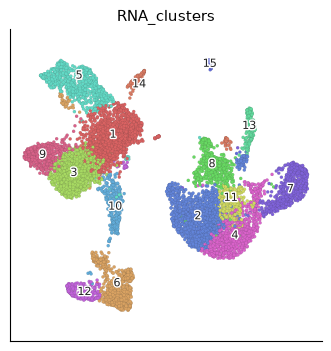

In [2]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_clusters',
)

In [3]:
ds.set_feature_selection(
    feature_indexes=range(ds.RNA.feats.N),
    label='all_for_markers',
)
all_features = ds.resolve_features('RNA', 'all_features')
marker_ref = ds.run_marker_search(
    group_key='RNA_clusters',
    cell_key='I',
    features=all_features,
)
markers = ds.get_markers(
    marker=marker_ref,
    cell_key='I',
    group_key='RNA_clusters',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1,
)
markers[
    [
        'feature_name',
        'score',
        'frac_exp',
        'auc',
        'p_value',
        'p_value_adjusted',
    ]
].head()

Finding markers: 2 / 2 complete

,feature_name,score,frac_exp,auc,p_value,p_value_adjusted
0,TMEM173,0.34733,0.15920,0.56513,9.037740e-87,2.477384e-84
1,GPR171,0.29714,0.19165,0.57550,4.090981e-91,1.214851e-88
2,RP11-1399P15.1,0.26977,0.08733,0.53701,7.981682e-56,1.269764e-53
3,PERP,0.25749,0.10046,0.53987,1.263935e-48,1.780249e-46
4,SETD2,0.23433,0.20556,0.57547,2.538191e-75,5.688581e-73


Aggregating marker values per group: 2 / 2 complete

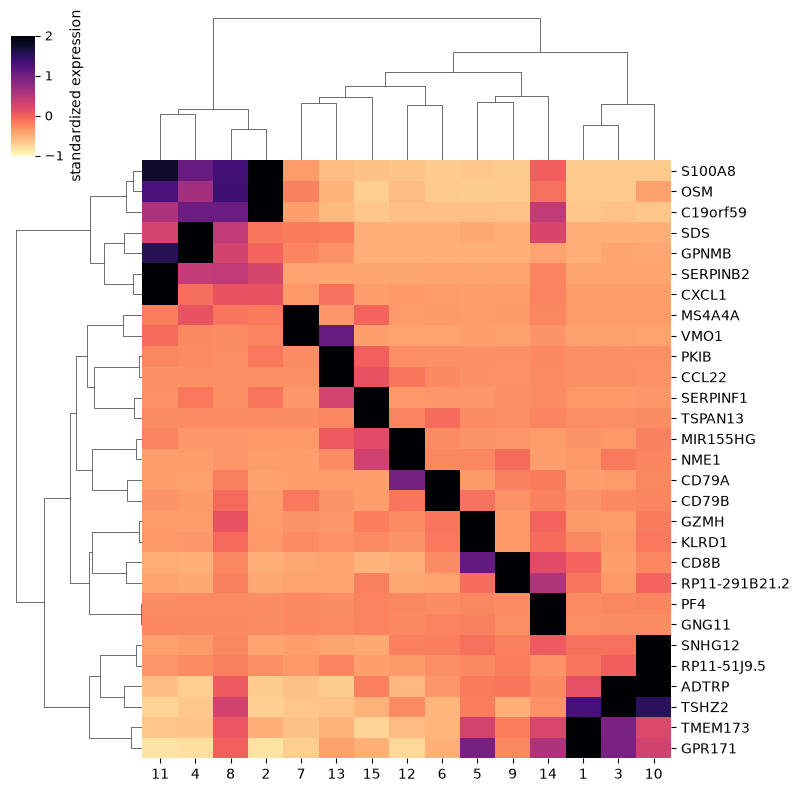

In [4]:
ds.plots.marker_heatmap(
    marker=marker_ref,
    group_key='RNA_clusters',
    cell_key='I',
    topn=2,
    figsize=(8, 8),
)

In [5]:
# Compare two clusters that are present in the Kang dataset.
result = ds.run_statistical_testing(
    ['MALAT1'],
    group_by='RNA_clusters',
    groups=[1, 2],
    test='welch',
    alternative='greater',
)

# Pin retrieval to the exact immutable result returned by the run.
loaded = ds.get_statistical_tests(artifact=result.artifact)
loaded.tables['MALAT1']

/home/parashar/scarf/scarf/datastore/_operations/features.py:2989: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


,group_1,group_2,n_1,n_2,t_statistic,df,mean_1,mean_2,mean_difference,p_value,p_value_adjusted
0,1,2,1294,1226,34.463603,2517.958201,68.815317,42.61835,26.196967,7.299045e-214,7.299045e-214


In [6]:
# The plotted selection and test design must match the stored result.
figure = ds.plots.distribution(
    ['MALAT1'],
    group_by='RNA_clusters',
    groups=[1, 2],
    kind='violin',
    stats_results=result,
    show=False,
)

In [7]:
group_sizes = (
    ds.cells.to_pandas_dataframe(
        columns=['RNA_clusters'],
        key='I',
    )['RNA_clusters']
    .astype(str)
    .value_counts()
    .sort_index()
)
group_sizes

RNA_clusters
1     1294
10     299
11     296
12     218
13     153
14     124
15      44
2     1226
3     1107
4      746
5      708
6      653
7      593
8      537
9      488
Name: count, dtype: int64

In [8]:
bulk, fracs = ds.make_bulk(
    group_key='RNA_clusters',
    aggr_type='sum',
    feature_label='name',
    return_fraction=True,
)
totals = bulk.sum().rename('total_counts')
totals.index = totals.index.astype(str)
pd.concat(
    [group_sizes.rename('n_cells'), totals],
    axis=1,
)

Aggregating pseudo-replicates: 15 / 15 complete

,n_cells,total_counts
1,1294,1985562
10,299,508230
11,296,856673
12,218,462058
13,153,588737
14,124,216654
15,44,118662
2,1226,2547306
3,1107,1419334
4,746,2047414


In [9]:
top_genes = bulk.sum(axis=1).sort_values(ascending=False).head(8).index
bulk.loc[top_genes]

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
FTH1,95520,395186,29776,315915,26812,27855,276690,190502,9121,11102,156887,6992,42382,19940,3115
MALAT1,133698,105409,112698,66409,78843,71993,93077,81723,50693,33849,27774,23697,26927,11454,6672
FTL,4359,188854,2687,205387,2887,3663,65389,92515,1749,1829,86052,3008,13839,8535,4002
B2M,55069,68050,37621,58264,42370,29801,59681,45872,19481,10897,23900,11308,18284,6897,2845
TMSB4X,75136,47190,43926,39156,44479,17849,72938,38583,20458,10687,11956,5193,31771,7858,2298
RPL10,25936,13181,20765,8961,11036,12339,8345,12256,9907,3690,3086,4524,4073,1772,829
TIMP1,602,42505,255,25648,307,128,32178,16833,78,144,11747,135,6315,1241,12
RPS2,25972,11695,19440,7734,11334,12952,8129,11013,9716,3401,2460,5440,3430,1663,929


In [10]:
fracs.loc[top_genes]

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
FTH1,0.998454,1.000000,0.998193,1.000000,0.995763,1.00000,1.000000,1.000000,0.995902,0.986622,1.000000,0.990826,1.000000,1.000000,1.000000
MALAT1,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.983871,1.000000
FTL,0.894127,1.000000,0.813911,1.000000,0.918079,0.97856,1.000000,1.000000,0.922131,0.872910,1.000000,0.986239,1.000000,0.975806,1.000000
B2M,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
TMSB4X,1.000000,0.996737,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,0.993311,1.000000,0.990826,1.000000,1.000000,1.000000
RPL10,1.000000,0.991028,0.999097,0.998660,0.997175,1.00000,0.996627,1.000000,1.000000,0.979933,0.993243,1.000000,0.993464,0.975806,1.000000
TIMP1,0.268161,1.000000,0.157182,0.998660,0.271186,0.14242,1.000000,1.000000,0.149590,0.180602,1.000000,0.155963,0.993464,0.669355,0.227273
RPS2,1.000000,0.995106,1.000000,0.994638,1.000000,1.00000,0.993255,0.998138,1.000000,0.973244,0.976351,1.000000,0.993464,0.967742,1.000000


In [11]:
bulk_reps = ds.make_bulk(
    group_key='RNA_clusters',
    aggr_type='sum',
    feature_label='name',
    pseudo_reps=2,
)
list(bulk_reps.columns)

Aggregating pseudo-replicates: 15 / 15 complete

['1_Rep1',
 '1_Rep2',
 '2_Rep1',
 '2_Rep2',
 '3_Rep1',
 '3_Rep2',
 '4_Rep1',
 '4_Rep2',
 '5_Rep1',
 '5_Rep2',
 '6_Rep1',
 '6_Rep2',
 '7_Rep1',
 '7_Rep2',
 '8_Rep1',
 '8_Rep2',
 '9_Rep1',
 '9_Rep2',
 '10_Rep1',
 '10_Rep2',
 '11_Rep1',
 '11_Rep2',
 '12_Rep1',
 '12_Rep2',
 '13_Rep1',
 '13_Rep2',
 '14_Rep1',
 '14_Rep2',
 '15_Rep1',
 '15_Rep2']

In [12]:
bulk_reps.shape

(16909, 30)

In [13]:
export_path = 'scarf_datasets/kang_pseudobulk_counts.csv'
meta_path = 'scarf_datasets/kang_pseudobulk_sample_meta.csv'
bulk.to_csv(export_path)
sample_meta = pd.concat(
    [group_sizes.rename('n_cells'), totals],
    axis=1,
)
sample_meta.index.name = 'group'
sample_meta.to_csv(meta_path)
print(f'Wrote {bulk.shape[0]} features x {bulk.shape[1]} groups to {export_path}')
print(f'Wrote sample metadata for {sample_meta.shape[0]} groups to {meta_path}')

Wrote 16909 features x 15 groups to scarf_datasets/kang_pseudobulk_counts.csv
Wrote sample metadata for 15 groups to scarf_datasets/kang_pseudobulk_sample_meta.csv


In [14]:
pd.read_csv(export_path, index_col=0, nrows=5).iloc[:, :5]

,1,2,3,4,5
RP11-34P13.8,0,1,0,0,0
AL627309.1,1,0,1,0,0
RP11-206L10.2,0,1,0,0,0
RP11-206L10.9,0,0,0,1,1
FAM87B,0,0,0,0,0


In [15]:
pd.read_csv(meta_path, index_col=0)

,n_cells,total_counts
group,,
1,1294,1985562
10,299,508230
11,296,856673
12,218,462058
13,153,588737
14,124,216654
15,44,118662
2,1226,2547306
3,1107,1419334
